# Environment Analysis

This notebook analyzes selected environmental indicators from the World Development Indicators dataset.

The analysis focuses on two main environmental indicators:

- CO2 emissions
- Energy use

The same selected countries used in the Economy and Population & Society notebooks are used here to maintain consistency across the project.

## 1. Load the Dataset

The dataset is downloaded from Kaggle and extracted into the Colab environment.

The main file used in this analysis is the SQLite database:
`database.sqlite`

In [1]:
#!pip install q kaggle
import os
os.environ['KAGGLE_CONFIG_DIR']='/content'

In [2]:
!kaggle datasets download -d kaggle/world-development-indicators

!unzip -q world-development-indicators.zip -d /content/world_development

Dataset URL: https://www.kaggle.com/datasets/kaggle/world-development-indicators
License(s): world-bank
100% 369M/369M [00:01<00:00, 217MB/s]



## 2. Import Required Libraries

The analysis uses Python libraries for:

- Connecting to and querying the SQLite database
- Data manipulation and analysis
- Data visualization

In [3]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 3. Connect to the Database

The World Development Indicators dataset is stored in a SQLite database.

A connection is established to access the available tables and retrieve the required environmental indicators using SQL queries.

In [4]:
database = '/content/world_development/database.sqlite'
conn = sqlite3.connect(database)

## 4. Explore the Database

Before starting the analysis, the database structure and available indicators are explored.

This helps identify the relevant tables and confirm the exact indicator names used for CO2 emissions and energy use.

In [5]:
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type = 'table';
""", conn)

tables

,name
0,Country
1,CountryNotes
2,Series
3,Indicators
4,SeriesNotes
5,Footnotes


In [6]:
pd.read_sql("SELECT DISTINCT IndicatorName FROM Indicators WHERE IndicatorName LIKE '%CO2 emissions%';", conn)

,IndicatorName
0,CO2 emissions (kg per 2005 US$ of GDP)
1,CO2 emissions (kg per 2011 PPP $ of GDP)
2,CO2 emissions (kg per PPP $ of GDP)
3,CO2 emissions (kt)
4,CO2 emissions (metric tons per capita)
5,CO2 emissions from electricity and heat produc...
6,CO2 emissions from gaseous fuel consumption (%...
7,CO2 emissions from gaseous fuel consumption (kt)
8,CO2 emissions from liquid fuel consumption (% ...
9,CO2 emissions from liquid fuel consumption (kt)


In [7]:
pd.read_sql("SELECT DISTINCT IndicatorName FROM Indicators WHERE IndicatorName LIKE '%Energy use%';", conn)

,IndicatorName
0,Alternative and nuclear energy (% of total ene...
1,CO2 intensity (kg per kg of oil equivalent ene...
2,"Energy imports, net (% of energy use)"
3,Energy use (kg of oil equivalent per capita)
4,"Energy use (kg of oil equivalent) per $1,000 G..."
5,GDP per unit of energy use (PPP $ per kg of oi...
6,GDP per unit of energy use (constant 2011 PPP ...


## 5. Data Selection

To maintain consistency across the project, the same selected countries used in the Economy and Population & Society notebooks are used here.

The selected countries are:

- Egypt
- Iran
- Iraq
- Libya
- Morocco
- Saudi Arabia
- Tunisia
- United Arab Emirates
- West Bank and Gaza
- Yemen
- Syrian Arab Republic

In [8]:
selected_country_codes = [
    'EGY',
    'IRN',
    'IRQ',
    'LBY',
    'MAR',
    'SAU',
    'TUN',
    'ARE',
    'WBG',
    'YEM',
    'SYR'
]

In [9]:
country_table = pd.read_sql("""
SELECT CountryCode, TableName AS CountryName
FROM Country
WHERE CountryCode IN (
    'EGY', 'IRN', 'IRQ', 'LBY', 'MAR',
    'SAU', 'TUN', 'ARE', 'WBG', 'YEM', 'SYR'
)
""", conn)

country_table

,CountryCode,CountryName
0,EGY,"Egypt, Arab Rep."
1,IRN,"Iran, Islamic Rep."
2,IRQ,Iraq
3,LBY,Libya
4,MAR,Morocco
5,SAU,Saudi Arabia
6,SYR,Syrian Arab Republic
7,TUN,Tunisia
8,ARE,United Arab Emirates
9,WBG,West Bank and Gaza


## 6. CO2 Emissions

CO2 emissions are analyzed over time for the selected countries.

The analysis uses the indicator:

**CO2 emissions (metric tons per capita)**

In [10]:
co2_emissions = pd.read_sql("""
SELECT CountryName, Year, Value
FROM Indicators
WHERE IndicatorName = 'CO2 emissions (metric tons per capita)'
AND CountryCode IN (
    'EGY', 'IRN', 'IRQ', 'LBY', 'MAR',
    'SAU', 'TUN', 'ARE', 'WBG', 'YEM', 'SYR'
)
ORDER BY CountryName, Year
""", conn)

co2_emissions.head()

,CountryName,Year,Value
0,"Egypt, Arab Rep.",1960,0.593007
1,"Egypt, Arab Rep.",1961,0.614463
2,"Egypt, Arab Rep.",1962,0.651081
3,"Egypt, Arab Rep.",1963,0.735083
4,"Egypt, Arab Rep.",1964,0.848084


In [11]:
co2_emissions.shape

(535, 3)

### CO2 Emissions Over Time

The line chart shows how CO2 emissions per capita changed over time across the selected countries.

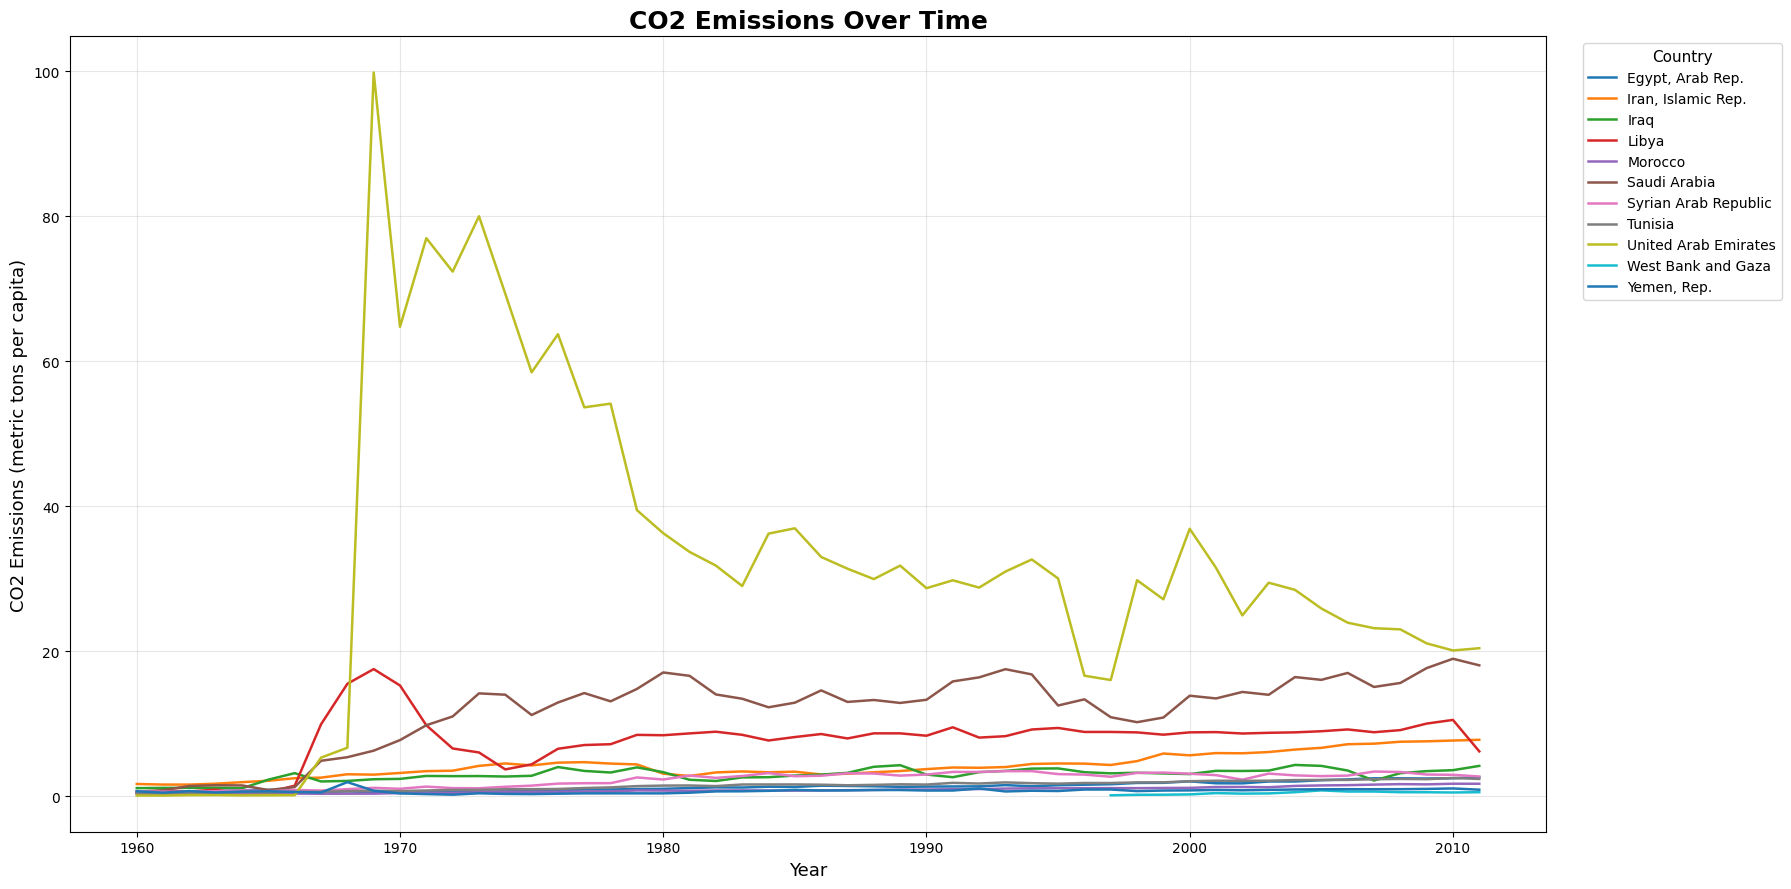

In [12]:
plt.figure(figsize=(18, 9))

for country in co2_emissions["CountryName"].unique():
    country_data = co2_emissions[co2_emissions["CountryName"] == country]

    plt.plot(
        country_data["Year"],
        country_data["Value"],
        label=country,
        linewidth=1.8
    )

plt.xlabel("Year", fontsize=13)
plt.ylabel("CO2 Emissions (metric tons per capita)", fontsize=13)

plt.title(
    "CO2 Emissions Over Time",
    fontsize=18,
    fontweight="bold"
)

plt.grid(True, alpha=0.3)

plt.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()

### Average CO2 Emissions by Country

The bar chart shows the average CO2 emissions per capita for each selected country across all available years.

In [13]:
average_co2 = co2_emissions.groupby("CountryName")["Value"].mean()

average_co2

,Value
CountryName,
"Egypt, Arab Rep.",1.351751
"Iran, Islamic Rep.",4.271025
Iraq,2.982146
Libya,7.748688
Morocco,0.890643
Saudi Arabia,11.862319
Syrian Arab Republic,2.300493
Tunisia,1.482407
United Arab Emirates,31.844877


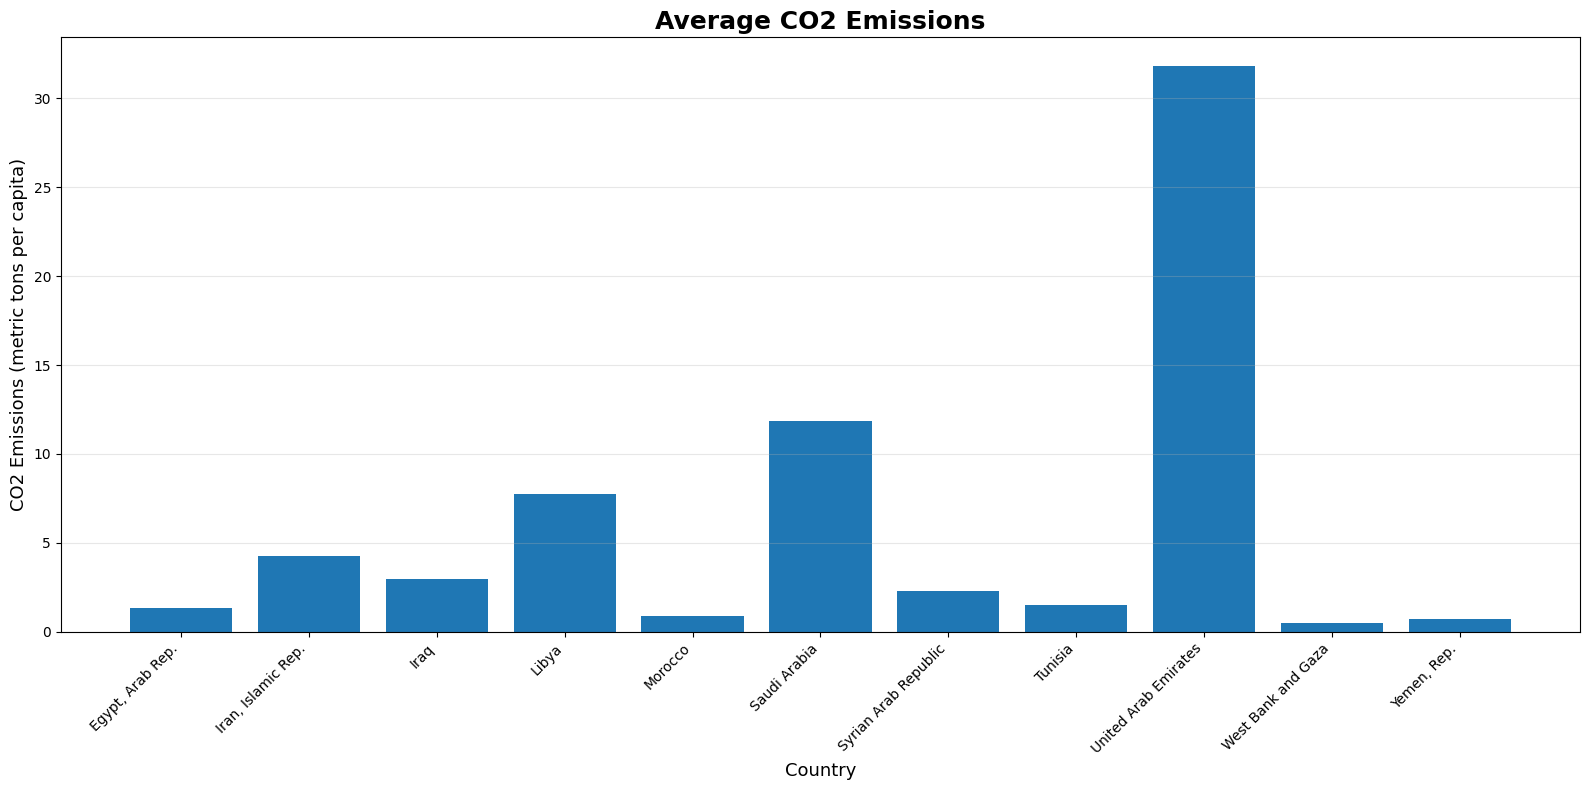

In [14]:
plt.figure(figsize=(16, 8))

plt.bar(
    average_co2.index,
    average_co2.values
)

plt.xlabel("Country", fontsize=13)
plt.ylabel("CO2 Emissions (metric tons per capita)", fontsize=13)

plt.title(
    "Average CO2 Emissions",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### CO2 Emissions Comparison (Latest Year)

The bar chart compares CO2 emissions per capita across the selected countries in the most recent year available in the dataset.

In [15]:
latest_co2_year = co2_emissions["Year"].max()

co2_latest = co2_emissions[co2_emissions["Year"] == latest_co2_year]

co2_latest

,CountryName,Year,Value
51,"Egypt, Arab Rep.",2011,2.635115
103,"Iran, Islamic Rep.",2011,7.802145
155,Iraq,2011,4.201635
207,Libya,2011,6.204914
259,Morocco,2011,1.737916
311,Saudi Arabia,2011,18.072451
363,Syrian Arab Republic,2011,2.736991
415,Tunisia,2011,2.402456
467,United Arab Emirates,2011,20.433838
482,West Bank and Gaza,2011,0.572407


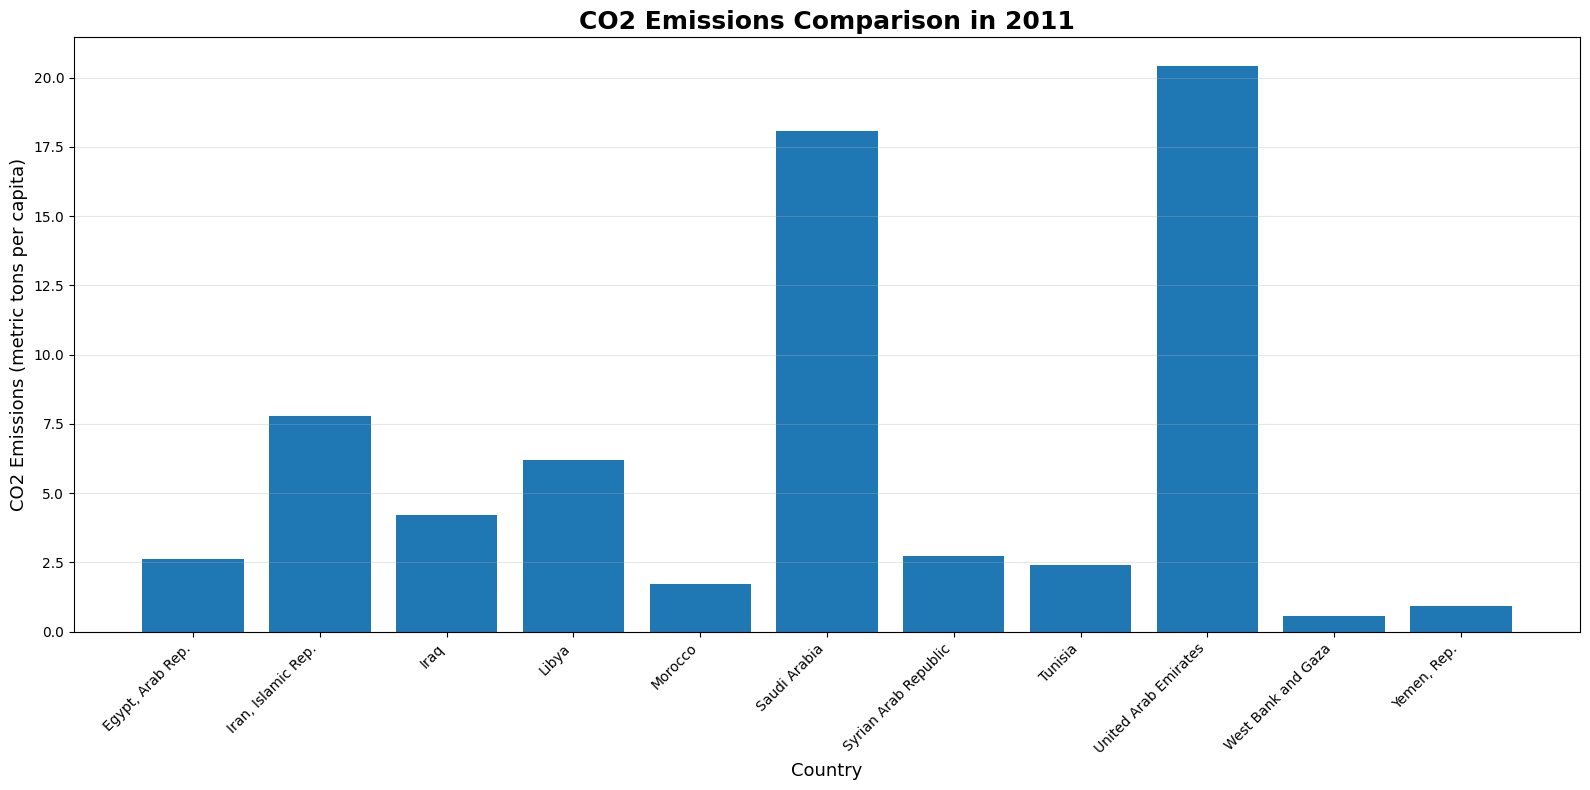

In [16]:
plt.figure(figsize=(16, 8))

plt.bar(
    co2_latest["CountryName"],
    co2_latest["Value"]
)

plt.xlabel("Country", fontsize=13)
plt.ylabel("CO2 Emissions (metric tons per capita)", fontsize=13)

plt.title(
    f"CO2 Emissions Comparison in {latest_co2_year}",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 7. Energy Use

Energy use is analyzed for the same selected countries.

The analysis uses the indicator:

**Energy use (kg of oil equivalent per capita)**

In [17]:
energy_use = pd.read_sql("""
SELECT CountryName, Year, Value
FROM Indicators
WHERE IndicatorName = 'Energy use (kg of oil equivalent per capita)'
AND CountryCode IN (
    'EGY', 'IRN', 'IRQ', 'LBY', 'MAR',
    'SAU', 'TUN', 'ARE', 'WBG', 'YEM', 'SYR'
)
ORDER BY CountryName, Year
""", conn)

energy_use.head()

,CountryName,Year,Value
0,"Egypt, Arab Rep.",1971,219.535753
1,"Egypt, Arab Rep.",1972,237.124882
2,"Egypt, Arab Rep.",1973,216.309600
3,"Egypt, Arab Rep.",1974,237.444685
4,"Egypt, Arab Rep.",1975,253.843955


### Energy Use Over Time

The line chart shows how energy use per capita changed over time across the selected countries.

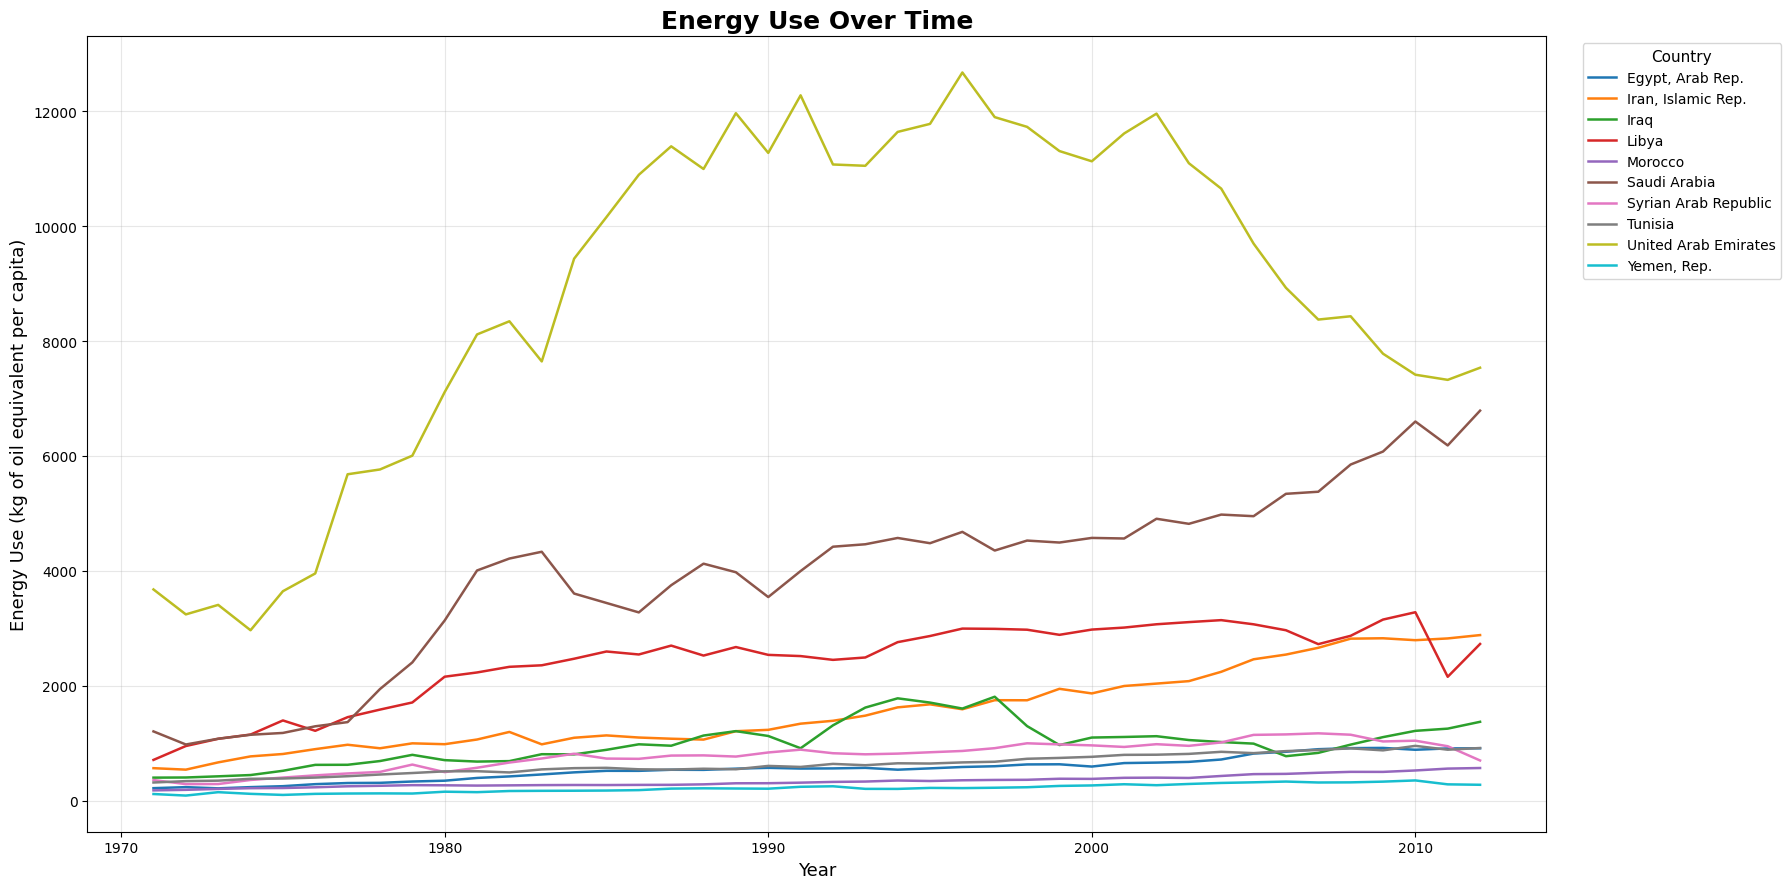

In [18]:
plt.figure(figsize=(18, 9))

for country in energy_use["CountryName"].unique():
    country_data = energy_use[energy_use["CountryName"] == country]

    plt.plot(
        country_data["Year"],
        country_data["Value"],
        label=country,
        linewidth=1.8
    )

plt.xlabel("Year", fontsize=13)
plt.ylabel("Energy Use (kg of oil equivalent per capita)", fontsize=13)

plt.title(
    "Energy Use Over Time",
    fontsize=18,
    fontweight="bold"
)

plt.grid(True, alpha=0.3)

plt.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()

### Average Energy Use by Country

The bar chart shows the average energy use per capita for each selected country across all available years.

In [ ]:
average_energy = energy_use.groupby("CountryName")["Value"].mean().sort()

average_energy

,Value
CountryName,
"Egypt, Arab Rep.",558.814299
"Iran, Islamic Rep.",1569.410578
Iraq,997.968594
Libya,2419.478357
Morocco,341.489532
Saudi Arabia,3929.717418
Syrian Arab Republic,782.429592
Tunisia,635.568704
United Arab Emirates,8881.962235


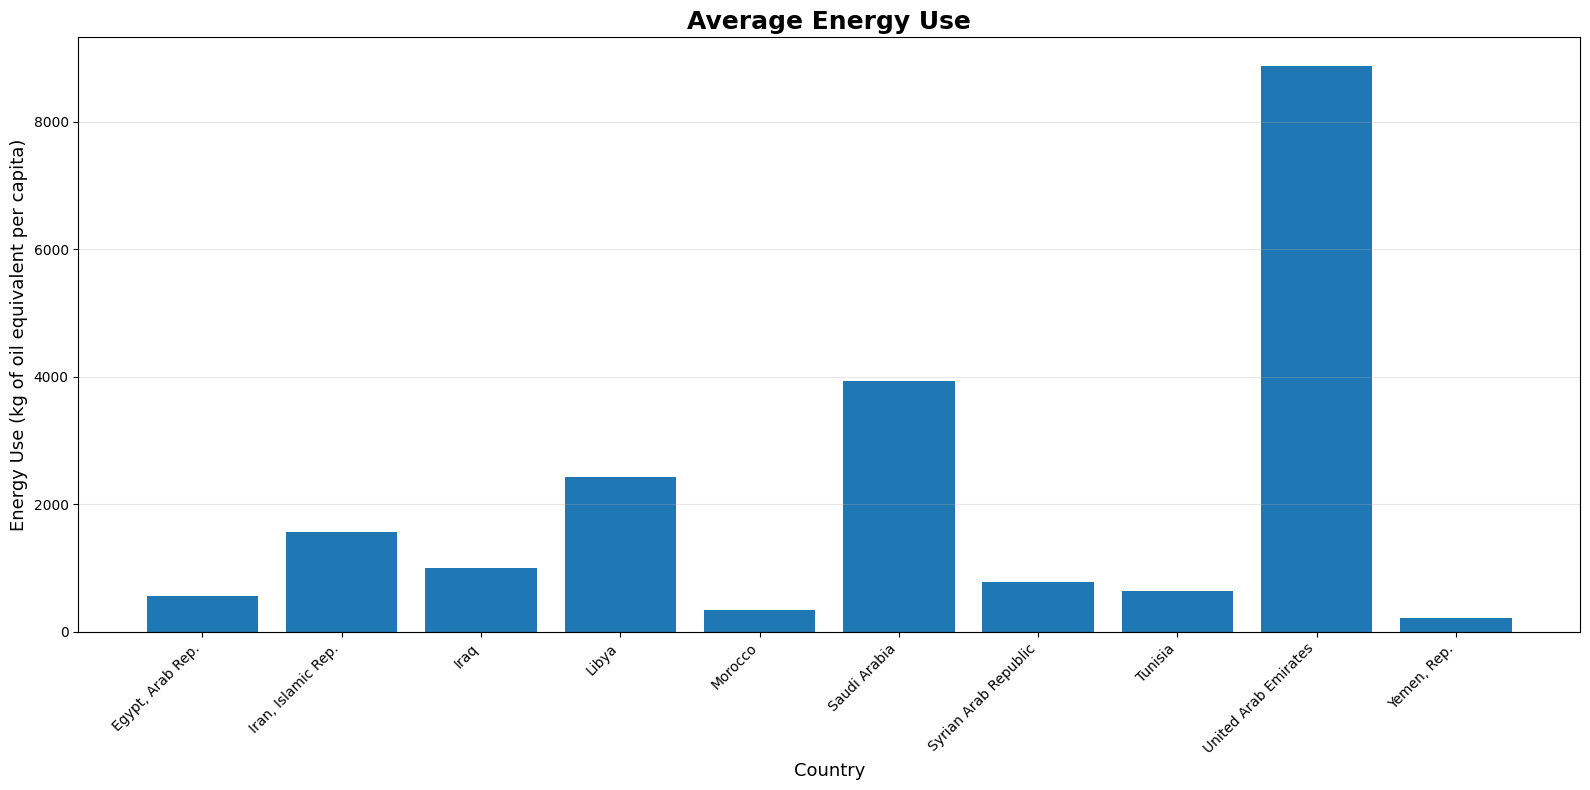

In [20]:
plt.figure(figsize=(16, 8))

plt.bar(
    average_energy.index,
    average_energy.values
)

plt.xlabel("Country", fontsize=13)
plt.ylabel("Energy Use (kg of oil equivalent per capita)", fontsize=13)

plt.title(
    "Average Energy Use",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Energy Use Comparison (Latest Year)

The bar chart compares energy use per capita across the selected countries in the most recent year available in the dataset.

In [21]:
latest_energy_year = energy_use["Year"].max()

energy_latest = energy_use[energy_use["Year"] == latest_energy_year]

energy_latest

,CountryName,Year,Value
41,"Egypt, Arab Rep.",2012,913.061387
83,"Iran, Islamic Rep.",2012,2883.393307
125,Iraq,2012,1374.108061
167,Libya,2012,2728.673141
209,Morocco,2012,569.911191
251,Saudi Arabia,2012,6789.243182
293,Syrian Arab Republic,2012,701.197149
335,Tunisia,2012,917.995361
377,United Arab Emirates,2012,7536.240768
419,"Yemen, Rep.",2012,278.241204


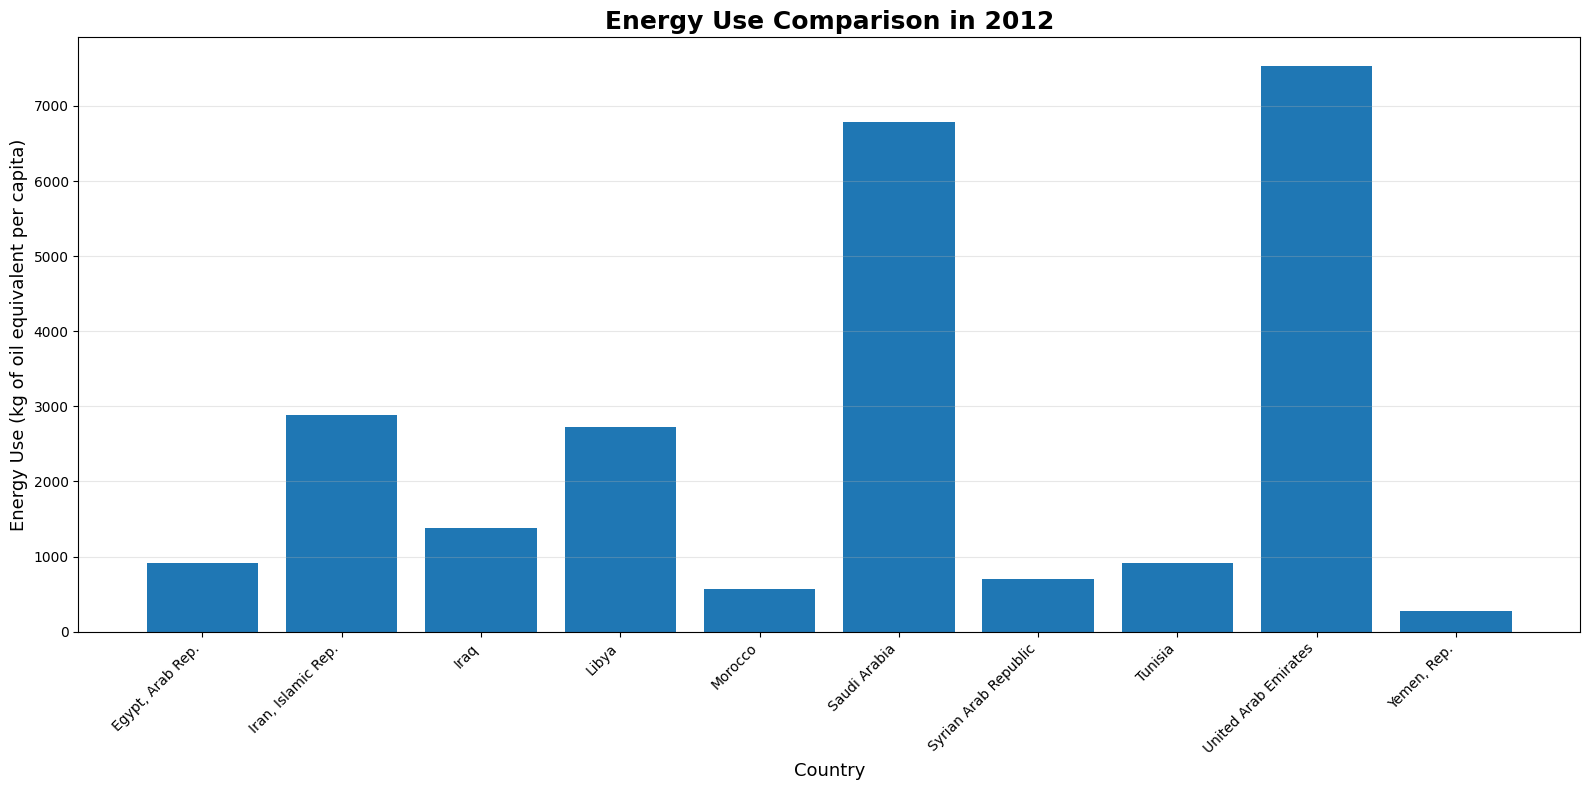

In [22]:
plt.figure(figsize=(16, 8))

plt.bar(
    energy_latest["CountryName"],
    energy_latest["Value"]
)

plt.xlabel("Country", fontsize=13)
plt.ylabel("Energy Use (kg of oil equivalent per capita)", fontsize=13)

plt.title(
    f"Energy Use Comparison in {latest_energy_year}",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 8. CO2 Emissions vs Energy Use

To provide a simple country-level comparison, the country averages for both environmental indicators are combined into one table and chart.

Because the two indicators have different units and numerical ranges, the chart should be interpreted as a descriptive comparison rather than evidence of a causal relationship.

In [23]:
comparison = pd.DataFrame({
    "Avg_CO2_Emissions": average_co2,
    "Avg_Energy_Use": average_energy
})

comparison.sort_values("Avg_CO2_Emissions", ascending=False)

,Avg_CO2_Emissions,Avg_Energy_Use
CountryName,,
United Arab Emirates,31.844877,8881.962235
Saudi Arabia,11.862319,3929.717418
Libya,7.748688,2419.478357
"Iran, Islamic Rep.",4.271025,1569.410578
Iraq,2.982146,997.968594
Syrian Arab Republic,2.300493,782.429592
Tunisia,1.482407,635.568704
"Egypt, Arab Rep.",1.351751,558.814299
Morocco,0.890643,341.489532


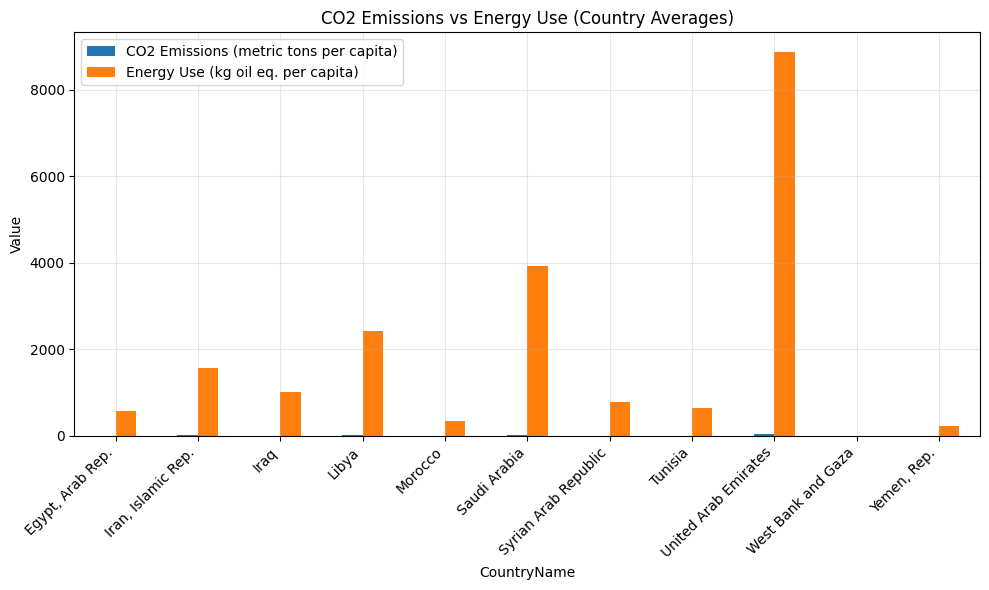

In [24]:
comparison.plot(kind="bar", figsize=(10, 6))
plt.title("CO2 Emissions vs Energy Use (Country Averages)")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.legend(["CO2 Emissions (metric tons per capita)", "Energy Use (kg oil eq. per capita)"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Next Steps

This notebook covers the Environment part of the project (CO2 emissions and energy use).

The remaining responsibility for this part of the project is to combine the outputs of all three notebooks (Economy, Population & Society, Environment) into a single PowerPoint presentation, once the fixes identified in the Economy and Population & Society notebooks are applied.